# Классификация автоматизированного трафика Авито (Entry Task)

## Цель
Построить модель, которая для каждой `cookie_id` присваивает `score` от 0 до 1:
чем выше значение, тем вероятнее, что трафик относится к известным сервисам автоматизированного сбора данных.

Основная метрика задачи — **Precision при Recall ≥ 0.7**.

Основные результаты на временной валидации P@R≥0.70:

**baseline CatBoost** — 0.3590 

**модель с 65 признаками** — 0.7586

**ансамбль двух CatBoost** — 0.8056 

**CatBoost с признаками пересечения посетителей** — 0.8593

**Финальный результат submission.csv** - 0.88472

## 0. Краткое описание Ноутбука

1. Проверка конфигурации и зависимостей
2. Анализ данных по train, test и событиям
3. Построение baseline и его проверка (начальные фичи + Catboost = PR@Rec>0.7 = 0.35)
4. Улучшение baseline поведенческими признаками и историей объявлений: 
сравниваем варианты на временных срезах и анализируем важность
признаков. 
5. Итоговый подход - CatBoost-модель с использованием 65 признаков поведения, 6
агрегатов истории просмотров и избранного за три прошедних дня и 4
признака пересечения с прежними размеченными посетителями объявлений.
6. Создание `submission.csv`.


## 1. Конфигурация и зависимости

Для воспроизведения фиксируем seed и объявляем версии библиотек. 

Данные находятся в `data/` рядом с ноутбуком (на github их не загружаю, считаю, что это не помешает "воспроизводимости" и явлется более правильным подходом)

`metric.py` — официальная метрика на которой ведется подсчет в ноутбуке

Запуск создаёт только итоговый `submission.csv`. 

версия Python — 3.13.


In [44]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("RANDOM_STATE:", RANDOM_STATE)


Python: 3.13.7
NumPy: 2.5.3
Pandas: 3.0.6
Scikit-learn: 1.9.1
RANDOM_STATE: 42


## 2. Проверка корректности загрузки данных

In [45]:
DATA_DIR = Path("data")

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
EVENTS_PATH = DATA_DIR / "events.csv.gz"
SAMPLE_SUBMISSION_PATH = Path("sample_submission.csv")

required_files = [
    TRAIN_PATH,
    TEST_PATH,
    EVENTS_PATH,
    SAMPLE_SUBMISSION_PATH,
]

missing_files = [str(path) for path in required_files if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Не найдены файлы:\n" + "\n".join(missing_files)
    )

print("Все файлы найдены.")


Все файлы найдены.


## 3. Загрузка данных

In [46]:
META_DATE_COLUMNS = [
    "cookie_created_at",
    "window_start_ts",
    "window_end_ts",
]

train = pd.read_csv(
    TRAIN_PATH,
    parse_dates=META_DATE_COLUMNS,
)

test = pd.read_csv(
    TEST_PATH,
    parse_dates=META_DATE_COLUMNS,
)

events = pd.read_csv(
    EVENTS_PATH,
    parse_dates=["event_ts"],
)

sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print("train:", train.shape)
print("test:", test.shape)
print("events:", events.shape)
print("sample_submission:", sample_submission.shape)

display(train.head())
display(test.head())
display(events.head())
display(sample_submission.head())


train: (11091, 5)
test: (4909, 4)
events: (328905, 14)
sample_submission: (4909, 2)


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


,cookie_id,cookie_created_at,window_start_ts,window_end_ts
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21
1,ck_a76ee3b3e3e522fd,2026-01-19 13:42:15,2026-04-20,2026-04-21
2,ck_94c9a4d382689e82,2026-04-19 06:28:37,2026-04-20,2026-04-21
3,ck_8eaf9509ad9462a0,2026-01-19 17:18:06,2026-04-20,2026-04-21
4,ck_9a88a5a989cb5bc6,2025-11-09 17:25:13,2026-04-20,2026-04-21


,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


,cookie_id,score
0,ck_99a4e5ef02d89493,0.5
1,ck_54d463f7fd89ec3d,0.5
2,ck_0fbbc7a6af300368,0.5
3,ck_8fd4937eadd64fb6,0.5
4,ck_dbb4bd4eda97255d,0.5


## 4. Анализ данных

### 4.1 Проверка train и test выборок

Проверим:
- число объектов
- уникальность `cookie_id`
- пересечение между train и test
- пропуски
- корректность целевой переменной
- временные диапазоны
- длительность окна наблюдения
- возраст cookie к началу окна


In [47]:
def dataframe_overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    return pd.DataFrame({
        "dataset": [name],
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "unique_cookie_id": [df["cookie_id"].nunique()],
        "duplicate_cookie_id": [df["cookie_id"].duplicated().sum()],
        "missing_cells": [int(df.isna().sum().sum())],
    })

overview = pd.concat(
    [
        dataframe_overview(train, "train"),
        dataframe_overview(test, "test"),
        dataframe_overview(events, "events"),
    ],
    ignore_index=True,
)

display(overview)


,dataset,rows,columns,unique_cookie_id,duplicate_cookie_id,missing_cells
0,train,11091,5,11091,0,0
1,test,4909,4,4909,0,0
2,events,328905,14,16000,312905,1202899


In [48]:
print("Распределение target:")
display(
    train["target"]
    .value_counts(dropna=False)
    .rename_axis("target")
    .to_frame("count")
    .assign(share=lambda x: x["count"] / x["count"].sum())
)


Распределение target:


,count,share
target,,
0,10192,0.918943
1,899,0.081057


#### Проверим окно наблюдения, а также расположение test и train во времени и cookie_age

In [49]:
def time_summary(df: pd.DataFrame, name: str) -> pd.Series:
    window_duration = df["window_end_ts"] - df["window_start_ts"]
    cookie_age = df["window_start_ts"] - df["cookie_created_at"]

    return pd.Series({
        "dataset": name,
        "window_start_min": df["window_start_ts"].min(),
        "window_start_max": df["window_start_ts"].max(),
        "window_end_min": df["window_end_ts"].min(),
        "window_end_max": df["window_end_ts"].max(),
        "window_duration_min": window_duration.min(),
        "window_duration_median": window_duration.median(),
        "window_duration_max": window_duration.max(),
        "cookie_age_min": cookie_age.min(),
        "cookie_age_median": cookie_age.median(),
        "cookie_age_max": cookie_age.max(),
    })

time_ranges = pd.DataFrame([
    time_summary(train, "train"),
    time_summary(test, "test"),
])

display(time_ranges.T)


,0,1
dataset,train,test
window_start_min,2026-04-06 00:00:00,2026-04-20 00:00:00
window_start_max,2026-04-19 00:00:00,2026-04-26 00:00:00
window_end_min,2026-04-07 00:00:00,2026-04-21 00:00:00
window_end_max,2026-04-20 00:00:00,2026-04-27 00:00:00
window_duration_min,1 days 00:00:00,1 days 00:00:00
window_duration_median,1 days 00:00:00,1 days 00:00:00
window_duration_max,1 days 00:00:00,1 days 00:00:00
cookie_age_min,0 days 00:17:48,0 days 00:29:16
cookie_age_median,59 days 18:13:13,58 days 15:08:45


#### Доли классов по датам

Проверим, меняются ли число cookie и доля положительного класса со временем.


In [50]:
daily_target = (
    train.assign(day=train["window_start_ts"].dt.date)
    .groupby("day")["target"]
    .agg(cookie_count="size", positive_count="sum", positive_share="mean")
)
daily_test_count = (
    test["window_start_ts"].dt.date.value_counts().sort_index()
)
display(daily_target)
display(daily_test_count.rename("test_cookie_count").to_frame())


,cookie_count,positive_count,positive_share
day,,,
2026-04-06,772,68,0.088083
2026-04-07,797,59,0.074028
2026-04-08,834,70,0.083933
2026-04-09,902,66,0.073171
2026-04-10,912,82,0.089912
2026-04-11,896,79,0.088170
2026-04-12,817,67,0.082007
2026-04-13,843,53,0.062871
2026-04-14,826,70,0.084746


,test_cookie_count
window_start_ts,
2026-04-20,652
2026-04-21,628
2026-04-22,637
2026-04-23,660
2026-04-24,760
2026-04-25,759
2026-04-26,813


### 4.2 Проверка таблицы событий

Проверим:
- диапазон времени событий
- количество уникальных cookie
- типы событий
- платформы
- пропуски
- полные дубли строк
- число событий на одну cookie


In [51]:
print("Число событий:", len(events))
print("Уникальных cookie_id в events:", events["cookie_id"].nunique())
print("Минимальный event_ts:", events["event_ts"].min())
print("Максимальный event_ts:", events["event_ts"].max())
print("Полных дублей строк:", events.duplicated().sum())


Число событий: 328905
Уникальных cookie_id в events: 16000
Минимальный event_ts: 2026-04-06 00:02:57
Максимальный event_ts: 2026-04-26 23:59:50
Полных дублей строк: 4863


#### Обработка полных совпадений строк

В данных есть события, которые совпадают по всем полям. 

У них нет уникального идентификатора, поэтому мы не можем точно сказать, повторная это запись или отдельное действие. 

Путем проверки нескольких подходов на временной валидации: удаление/не удаление дублей, лучше оказался подход с удалением полных дублей строк.


In [52]:
events_raw = events.copy()
events_before = len(events_raw)

events = events_raw.drop_duplicates().copy()

events_after = len(events)
print("Событий до удаления дублей:", events_before)
print("Событий после удаления дублей:", events_after)
print("Удалено дублей:", events_before - events_after)


Событий до удаления дублей: 328905
Событий после удаления дублей: 324042
Удалено дублей: 4863


In [53]:
event_types = (
    events["event_name"]
    .value_counts(dropna=False)
    .rename_axis("event_name")
    .to_frame("count")
)
event_types["share"] = event_types["count"] / len(events)

display(event_types)


,count,share
event_name,,
item_view,118990,0.367205
search_results_view,98929,0.305297
photo_swipe,35962,0.110979
favorite_add,18739,0.057829
seller_page_view,17180,0.053018
contact_phone_show,11154,0.034421
captcha_shown,7831,0.024167
login,6178,0.019065
contact_chat_open,6047,0.018661


Чаще всего встречаются просмотры объявлений и страниц поиска

In [54]:
platforms = (
    events["platform"]
    .value_counts(dropna=False)
    .rename_axis("platform")
    .to_frame("count")
)
platforms["share"] = platforms["count"] / len(events)

display(platforms)


,count,share
platform,,
desktop,46157,0.142441
WEB,45799,0.141337
Web,45703,0.141040
web,45284,0.139747
ANDROID,41809,0.129023
Android,41637,0.128493
android,41542,0.128199
iOS,4035,0.012452
iphone,4035,0.012452


Названия одних и тех же платформ записаны в разных регистрах и вариантах, поэтому перед использованием их нужно привести к единому виду

In [55]:
events_missing = (
    events.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_share")
    .to_frame()
)

display(events_missing)


,missing_share
search_query,0.694703
search_page,0.694703
pointer_x,0.669901
pointer_y,0.669901
seller_type,0.407009
item_id,0.348529
item_category,0.100166
item_location,0.072423
user_agent,0.000000
platform,0.000000


Чаще всего не заполнены поля поиска и координаты указателя, но основные поля события заполнены полностью

#### Просмотрим заполненность полей в зависимости от типа события


In [56]:
fields_to_check = [
    "item_id",
    "item_category",
    "item_location",
    "seller_type",
    "search_query",
    "search_page",
    "pointer_x",
    "pointer_y",
    "user_agent",
]

non_null_by_event = (
    events
    .groupby("event_name")[fields_to_check]
    .agg(lambda x: x.notna().mean())
    .round(3)
)

display(non_null_by_event)


,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y,user_agent
event_name,,,,,,,,,
captcha_shown,0.0,0.000,0.000,0.000,0.0,0.0,0.272,0.272,1.0
contact_chat_open,1.0,0.942,0.970,0.915,0.0,0.0,0.308,0.308,1.0
contact_message_sent,1.0,0.940,0.972,0.910,0.0,0.0,0.323,0.323,1.0
contact_phone_show,1.0,0.941,0.972,0.906,0.0,0.0,0.323,0.323,1.0
favorite_add,1.0,0.937,0.972,0.909,0.0,0.0,0.349,0.349,1.0
item_view,1.0,0.941,0.970,0.910,0.0,0.0,0.327,0.327,1.0
login,0.0,0.000,0.000,0.000,0.0,0.0,0.355,0.355,1.0
photo_swipe,1.0,0.942,0.968,0.912,0.0,0.0,0.342,0.342,1.0
search_results_view,0.0,0.940,0.969,0.000,1.0,1.0,0.331,0.331,1.0


Поля заполняются в зависимости от действия: поисковый запрос есть у search_results_view, а item_id  у действий с объявлением

### 4.3 Проверим события относительно окна наблюдения

```text
window_start_ts <= event_ts < window_end_ts
```


In [57]:
meta_all = pd.concat(
    [
        train[["cookie_id", "window_start_ts", "window_end_ts"]].assign(split="train"),
        test[["cookie_id", "window_start_ts", "window_end_ts"]].assign(split="test"),
    ],
    ignore_index=True,
)

# Подтягиваем границы окна по cookie; дальше все агрегаты строятся
# только по событиям с window_start_ts <= event_ts < window_end_ts.
events_with_window = events.merge(
    meta_all,
    on="cookie_id",
    how="left",
    validate="many_to_one",
)

events_with_window["window_position"] = np.select(
    [
        events_with_window["event_ts"] < events_with_window["window_start_ts"],
        events_with_window["event_ts"] >= events_with_window["window_end_ts"],
    ],
    [
        "before_window",
        "after_window",
    ],
    default="inside_window",
)

window_position_stats = (
    events_with_window["window_position"]
    .value_counts(dropna=False)
    .rename_axis("position")
    .to_frame("count")
)
window_position_stats["share"] = (
    window_position_stats["count"] / window_position_stats["count"].sum()
)

display(window_position_stats)


,count,share
position,,
inside_window,283833,0.875914
after_window,40209,0.124086


В суточное окно cookie попадают 87,6% событий

 остальные 12,4% произошли после его окончания, то есть для построения признаков использоваться не будут

In [58]:
events_in_window = events_with_window.loc[
    (events_with_window["event_ts"] >= events_with_window["window_start_ts"])
    & (events_with_window["event_ts"] < events_with_window["window_end_ts"])
].copy()

ev_train = events_in_window.loc[events_in_window["split"] == "train"].copy()
ev_test = events_in_window.loc[events_in_window["split"] == "test"].copy()

print("Событий внутри окна:")
print("train:", len(ev_train))
print("test:", len(ev_test))
print("total:", len(events_in_window))


Событий внутри окна:
train: 195484
test: 88349
total: 283833


#### События с одинаковой временной меткой

Время события имеет точность до секунды. При совпадении `event_ts` порядок строк не задан, поэтому расстояния между последовательными координатами могут зависеть от порядка выгрузки.

In [59]:
pointer_events = events_in_window.dropna(subset=["pointer_x", "pointer_y"])
pointer_second = pointer_events.groupby(["cookie_id", "event_ts"])
pointer_second_count = pointer_second.size()
pointer_second_unique = pointer_second[["pointer_x", "pointer_y"]].nunique()
ambiguous_pointer_second = (
    pointer_second_count.gt(1)
    & pointer_second_unique.gt(1).any(axis=1)
)
ambiguous_cookie_ids = set(
    ambiguous_pointer_second[ambiguous_pointer_second]
    .index.get_level_values("cookie_id")
)
print("Групп cookie + секунда с несколькими разными координатами:",
      int(ambiguous_pointer_second.sum()))
print("Затронуто cookie:", len(ambiguous_cookie_ids))
display(
    train.assign(неоднозначный_pointer=train["cookie_id"].isin(ambiguous_cookie_ids))
    .groupby("target")["неоднозначный_pointer"]
    .agg(число="sum", доля="mean")
)


Групп cookie + секунда с несколькими разными координатами: 535
Затронуто cookie: 433


,число,доля
target,,
0,290,0.028454
1,8,0.008899


Несколько разных координат указателя в одну секунду встречаются у 2,85% людей и 0,89% ботов, поэтому порядок таких событий может быть неоднозначным

### 4.4 Сравнение target = 0 и target = 1

Посмотрим на несколько простых характеристик поведения cookie


In [60]:
train_cookie_stats = (
    ev_train
    .groupby("cookie_id")
    .agg(
        n_events=("event_name", "size"),
        n_event_types=("event_name", "nunique"),
        n_items=("item_id", "nunique"),
    )
    .reset_index()
)

train_cookie_stats = (
    train[["cookie_id", "target"]]
    .merge(train_cookie_stats, on="cookie_id", how="left")
)

train_cookie_stats[
    ["n_events", "n_event_types", "n_items"]
] = train_cookie_stats[
    ["n_events", "n_event_types", "n_items"]
].fillna(0)

display(train_cookie_stats.head())


,cookie_id,target,n_events,n_event_types,n_items
0,ck_54a059eb7d3ea68b,0,7,3,4
1,ck_7e4de46eeab82974,0,41,7,19
2,ck_9320229ef6304522,0,36,9,19
3,ck_30ccd25bc1714ed9,0,21,5,10
4,ck_a77c5f05948cdeef,0,28,6,16


Для каждой cookie собраны число событий, число типов действий и число уникальных объявлений

#### Распределение количества событий на cookie


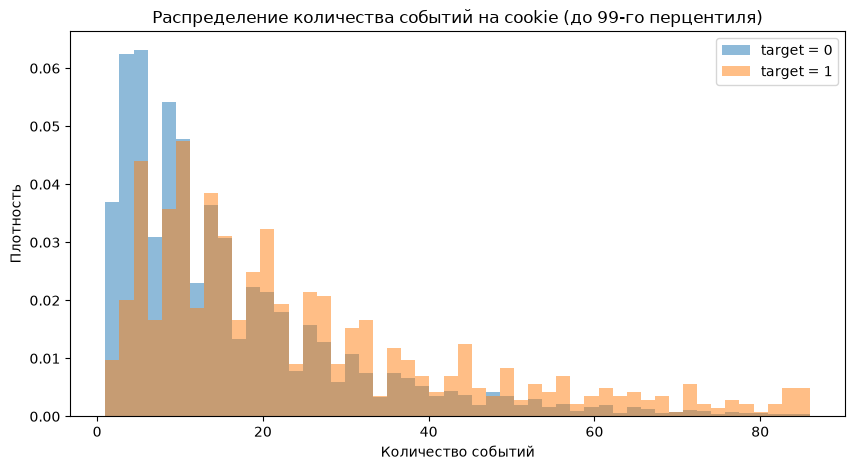

In [61]:
event_limit = train_cookie_stats["n_events"].quantile(0.99)

plt.figure(figsize=(10, 5))

for target in [0, 1]:
    values = train_cookie_stats.loc[
        (train_cookie_stats["target"] == target)
        & (train_cookie_stats["n_events"] <= event_limit),
        "n_events"
    ]

    plt.hist(
        values,
        bins=50,
        density=True,
        alpha=0.5,
        label=f"target = {target}",
    )

plt.xlabel("Количество событий")
plt.ylabel("Плотность")
plt.title("Распределение количества событий на cookie (до 99-го перцентиля)")
plt.legend()
plt.show()


У ботов немного чаще встречается высокая активность, но в целом распределения двух классов пересекаются

#### Распределение количества уникальных объявлений

Проверим, отличается ли масштаб просмотра различных объявлений между двумя классами.


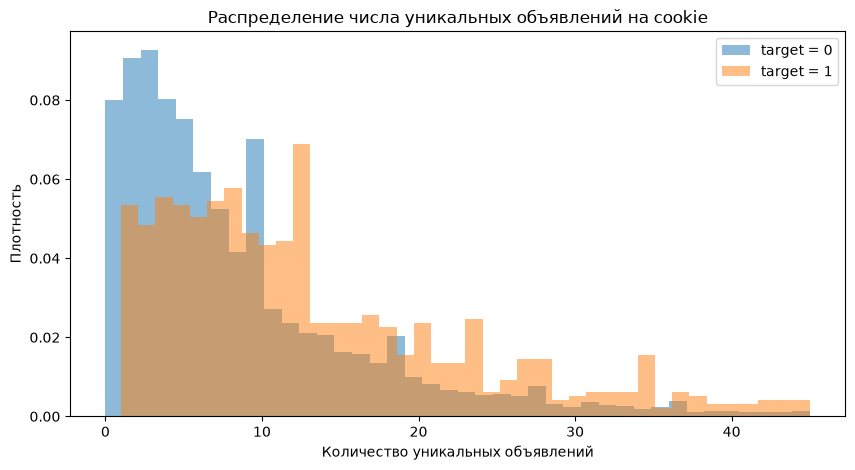

In [62]:
item_limit = train_cookie_stats["n_items"].quantile(0.99)

plt.figure(figsize=(10, 5))

for target in [0, 1]:
    values = train_cookie_stats.loc[
        (train_cookie_stats["target"] == target)
        & (train_cookie_stats["n_items"] <= item_limit),
        "n_items"
    ]

    plt.hist(
        values,
        bins=40,
        density=True,
        alpha=0.5,
        label=f"target = {target}",
    )

plt.xlabel("Количество уникальных объявлений")
plt.ylabel("Плотность")
plt.title("Распределение числа уникальных объявлений на cookie")
plt.legend()
plt.show()


Боты просматривают больше разных объявлений, а у людей чаще встречаются небольшие значения

#### Разнообразие типов событий

Сравним число различных `event_name`, встречающихся у одной cookie в пределах окна наблюдения.


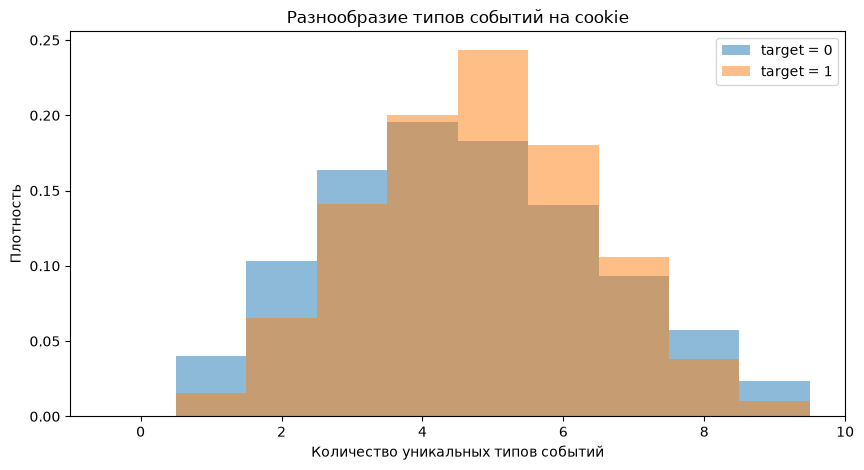

In [63]:
max_event_types = int(train_cookie_stats["n_event_types"].max())

plt.figure(figsize=(10, 5))

for target in [0, 1]:
    values = train_cookie_stats.loc[
        train_cookie_stats["target"] == target,
        "n_event_types"
    ]

    plt.hist(
        values,
        bins=np.arange(max_event_types + 2) - 0.5,
        density=True,
        alpha=0.5,
        label=f"target = {target}",
    )

plt.xlabel("Количество уникальных типов событий")
plt.ylabel("Плотность")
plt.title("Разнообразие типов событий на cookie")
plt.legend()
plt.show()


У ботов чаще 4–6 разных типов действий, но отделение от людей неоднозначное 

## 5. Baseline

Используем только базовые признаки, доступные к моменту окончания окна наблюдения:
- возраст cookie к началу окна
- количество событий
- число уникальных типов событий
- число уникальных объявлений, категорий, локаций, поисковых запросов и страниц
- число уникальных платформ и User-Agent
- количество событий каждого `event_name`


### 5.1 Формирование базовых признаков

Все поведенческие признаки считаются только по событиям, уже отфильтрованным по условию:

```text
window_start_ts <= event_ts < window_end_ts
```

Точные строки `cookie_id`, `item_id`, `search_query` и `user_agent` как категориальные признаки в baseline использовать не будем.


In [64]:
def build_baseline_features(ev: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    grouped = ev.groupby("cookie_id")

    features = pd.DataFrame({
        "n_events": grouped.size(),
        "n_event_types": grouped["event_name"].nunique(),
        "n_items": grouped["item_id"].nunique(),
        "n_categories": grouped["item_category"].nunique(),
        "n_locations": grouped["item_location"].nunique(),
        "n_search_queries": grouped["search_query"].nunique(),
        "n_search_pages": grouped["search_page"].nunique(),
        "n_platforms": grouped["platform"].nunique(),
        "n_user_agents": grouped["user_agent"].nunique(),
    })

    # Разные типы действий становятся отдельными счётчиками.
    event_counts = pd.crosstab(
        ev["cookie_id"],
        ev["event_name"],
    ).add_prefix("event_count__")

    features = features.join(event_counts, how="outer")

    result = meta[
        ["cookie_id", "cookie_created_at", "window_start_ts"]
    ].copy()

    result["cookie_age_hours"] = (
        result["window_start_ts"] - result["cookie_created_at"]
    ).dt.total_seconds() / 3600

    result = result.merge(
        features.reset_index(),
        on="cookie_id",
        how="left",
    )

    feature_columns = [
        column
        for column in result.columns
        if column not in {
            "cookie_id",
            "cookie_created_at",
            "window_start_ts",
        }
    ]

    result[feature_columns] = result[feature_columns].fillna(0)

    return result


baseline_train = build_baseline_features(ev_train, train)
baseline_test = build_baseline_features(ev_test, test)

display(baseline_train.head())

print("Размер baseline train:", baseline_train.shape)
print("Размер baseline test:", baseline_test.shape)


,cookie_id,cookie_created_at,window_start_ts,cookie_age_hours,n_events,n_event_types,n_items,n_categories,n_locations,n_search_queries,n_search_pages,n_platforms,n_user_agents,event_count__contact_chat_open,event_count__contact_message_sent,event_count__contact_phone_show,event_count__favorite_add,event_count__item_view,event_count__login,event_count__photo_swipe,event_count__search_results_view,event_count__seller_page_view
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,3254.488611,7,3,4,3,5,3,3,3,1,0,0,0,0,3,0,1,3,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,4669.826667,41,7,19,1,12,5,6,4,1,0,0,1,1,22,1,4,8,4
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,791.866111,36,9,19,7,9,10,7,4,1,1,1,2,3,7,3,3,13,3
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,13.122222,21,5,10,1,4,3,2,4,1,1,0,1,0,14,0,0,3,2
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2276.090278,28,6,16,4,6,6,4,4,1,0,0,1,2,12,0,4,6,3


Размер baseline train: (11091, 22)
Размер baseline test: (4909, 22)


Проверим, что train и test имеют одинаковый набор модельных признаков


In [65]:
BASE_FEATURES = [
    column
    for column in baseline_train.columns
    if column not in {"cookie_id", "cookie_created_at", "window_start_ts"}
]

missing_in_test = set(BASE_FEATURES) - set(baseline_test.columns)
extra_in_test = set(baseline_test.columns) - set(baseline_train.columns)
baseline_test = baseline_test.reindex(columns=baseline_train.columns, fill_value=0)

print("Количество baseline-признаков:", len(BASE_FEATURES))
print("Типы событий только в train:", sorted(missing_in_test))
print("Типы событий только в test:", sorted(extra_in_test))


Количество baseline-признаков: 19
Типы событий только в train: []
Типы событий только в test: []


### 5.2 Временная валидация

Train расположен раньше test. 

Модель проверяем на последних трёх днях train (17–19 апреля)


In [66]:
VALID_START = pd.Timestamp("2026-04-17")

is_valid = train["window_start_ts"].ge(VALID_START).to_numpy()

train_idx = ~is_valid
valid_idx = is_valid

X = baseline_train[BASE_FEATURES]
y = train["target"].to_numpy()

X_train = X.loc[train_idx]
X_valid = X.loc[valid_idx]

y_train = y[train_idx]
y_valid = y[valid_idx]

print("Train:")
print("  объектов:", len(X_train))
print("  доля target=1:", round(y_train.mean(), 4))
print(
    "  период:",
    train.loc[train_idx, "window_start_ts"].min(),
    "—",
    train.loc[train_idx, "window_start_ts"].max(),
)

print("\nValidation:")
print("  объектов:", len(X_valid))
print("  доля target=1:", round(y_valid.mean(), 4))
print(
    "  период:",
    train.loc[valid_idx, "window_start_ts"].min(),
    "—",
    train.loc[valid_idx, "window_start_ts"].max(),
)


Train:
  объектов: 9140
  доля target=1: 0.0809
  период: 2026-04-06 00:00:00 — 2026-04-16 00:00:00

Validation:
  объектов: 1951
  доля target=1: 0.082
  период: 2026-04-17 00:00:00 — 2026-04-19 00:00:00


### 5.3 Метрики

Основную метрику импортируем из `metric.py`

PR-AUC и ROC-AUC используем как дополнительные диагностические показатели.


In [67]:
from sklearn.metrics import average_precision_score, roc_auc_score
from metric import precision_at_recall


def evaluate_scores(
    y_true: np.ndarray,
    scores: np.ndarray,
    model_name: str,
) -> pd.Series:
    return pd.Series({
        "model": model_name,
        "P@R>=0.70": precision_at_recall(y_true, scores),
        "PR-AUC": average_precision_score(y_true, scores),
        "ROC-AUC": roc_auc_score(y_true, scores),
    })


### 5.4 CatBoost baseline model


In [68]:
from catboost import CatBoostClassifier

catboost_baseline = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)

catboost_baseline.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=100,
)

catboost_valid_scores = catboost_baseline.predict_proba(X_valid)[:, 1]

catboost_result = evaluate_scores(
    y_valid,
    catboost_valid_scores,
    "CatBoost",
)

display(catboost_result.to_frame().T)

print("Лучшее число итераций:", catboost_baseline.get_best_iteration())


,model,P@R>=0.70,PR-AUC,ROC-AUC
0,CatBoost,0.358974,0.567231,0.869771


Лучшее число итераций: 177


#### Feature importance для CatBoost


In [69]:
feature_importance = (
    pd.DataFrame({
        "feature": BASE_FEATURES,
        "importance": catboost_baseline.get_feature_importance(),
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(20))


,feature,importance
0,n_categories,16.691746
1,n_locations,14.778432
2,n_search_pages,11.023897
3,event_count__favorite_add,7.689912
4,event_count__photo_swipe,6.279914
5,cookie_age_hours,5.778458
6,event_count__contact_phone_show,5.561437
7,n_items,5.370249
8,n_platforms,4.521309
9,n_search_queries,3.410801


#### Итоги baseline:
**CatBoost**: `Precision @ Recall ≥ 0.70 = 0.3590`, `PR-AUC = 0.5672`, `ROC-AUC = 0.8698`. 

Наибольшую важность получили признаки, связанные с разнообразием поведения: число категорий, локаций и поисковых страниц, а также количество отдельных типов действий

Другие пробы моделей убрал из ноутбука чтобы не захломлять его, их значение метрики было хуже

В качестве основной baseline-модели фиксируем **CatBoost с P@R≥0.70 = 0.3590**.


## 6. Feature Engineering

Базовую модель будем строим из количества событий, времени активности и координат pointer. 

Отдельно проверим глубину поиска, соотношения действий, тип продавца и характеристики клиента. 

Все признаки будем считать по событиям внутри суточного окна.


### 6.1 Временная активность

Сортируем события каждой cookie по времени. 

Считаем длительность активности, интервалы и долю коротких пауз.


In [70]:
def build_temporal_features(ev: pd.DataFrame) -> pd.DataFrame:
    # Сортировка сохраняет исходный порядок при равном event_ts.
    ordered = ev.sort_values(
        ["cookie_id", "event_ts"],
        kind="mergesort",
    ).copy()

    # Интервал между соседними событиями одной cookie, в секундах.
    ordered["delta_seconds"] = (
        ordered
        .groupby("cookie_id")["event_ts"]
        .diff()
        .dt.total_seconds()
    )

    grouped = ordered.groupby("cookie_id")

    temporal = grouped["event_ts"].agg(
        first_event_ts="min",
        last_event_ts="max",
        n_events_temporal="size",
    )

    temporal["activity_duration_seconds"] = (
        temporal["last_event_ts"] - temporal["first_event_ts"]
    ).dt.total_seconds()

    delta_stats = (
        ordered
        .dropna(subset=["delta_seconds"])
        .groupby("cookie_id")["delta_seconds"]
        .agg(
            delta_mean="mean",
            delta_median="median",
            delta_std="std",
            delta_min="min",
            delta_max="max",
        )
    )

    delta_quantiles = (
        ordered
        .dropna(subset=["delta_seconds"])
        .groupby("cookie_id")["delta_seconds"]
        .quantile([0.10, 0.25, 0.75, 0.90])
        .unstack()
        .rename(columns={
            0.10: "delta_p10",
            0.25: "delta_p25",
            0.75: "delta_p75",
            0.90: "delta_p90",
        })
    )

    short_intervals = (
        ordered
        .dropna(subset=["delta_seconds"])
        .groupby("cookie_id")["delta_seconds"]
        .agg(
            share_delta_le_1s=lambda x: (x <= 1).mean(),
            share_delta_le_2s=lambda x: (x <= 2).mean(),
            share_delta_le_5s=lambda x: (x <= 5).mean(),
        )
    )

    temporal = temporal.join(delta_stats, how="left")
    temporal = temporal.join(delta_quantiles, how="left")
    temporal = temporal.join(short_intervals, how="left")

    # Коэффициент вариации интервалов: мера относительной регулярности.
    temporal["delta_cv"] = (
        temporal["delta_std"]
        / temporal["delta_mean"].replace(0, np.nan)
    )

    # Скорость активности. Для очень коротких последовательностей
    # знаменатель ограничиваем одной секундой.
    active_seconds = temporal["activity_duration_seconds"].clip(lower=1)

    temporal["events_per_active_minute"] = (
        temporal["n_events_temporal"]
        / active_seconds
        * 60
    )

    # Число минут, в которых происходило хотя бы одно событие.
    ordered["event_minute"] = ordered["event_ts"].dt.floor("min")
    active_minutes = (
        ordered
        .groupby("cookie_id")["event_minute"]
        .nunique()
        .rename("n_active_minutes")
    )

    temporal = temporal.join(active_minutes, how="left")

    temporal["events_per_active_minute_bin"] = (
        temporal["n_events_temporal"]
        / temporal["n_active_minutes"].clip(lower=1)
    )

    temporal = temporal.drop(
        columns=["first_event_ts", "last_event_ts"]
    )

    return temporal.reset_index()


temporal_train = build_temporal_features(ev_train)
temporal_test = build_temporal_features(ev_test)

TEMPORAL_FEATURES = [
    column for column in temporal_train.columns if column != "cookie_id"
]


### 6.2 Поведение pointer

Считаем разброс координат и расстояния между последовательными событиями с координатами. 

Не будем считать координаты считать непрерывной траекторией мыши.


In [71]:
def build_pointer_features(ev: pd.DataFrame) -> pd.DataFrame:
    pointer = (
        ev.loc[
            ev["pointer_x"].notna() & ev["pointer_y"].notna(),
            ["cookie_id", "event_ts", "pointer_x", "pointer_y"],
        ]
        .sort_values(["cookie_id", "event_ts"], kind="mergesort")
        .copy()
    )
    coords = pointer.groupby("cookie_id").agg(
        pointer_x_std=("pointer_x", "std"),
        pointer_x_min=("pointer_x", "min"),
        pointer_x_max=("pointer_x", "max"),
        pointer_y_min=("pointer_y", "min"),
        pointer_y_max=("pointer_y", "max"),
    )
    coords["pointer_x_range"] = coords["pointer_x_max"] - coords["pointer_x_min"]

    # Расстояние считаем между соседними событиями с координатами,
    previous_x = pointer.groupby("cookie_id")["pointer_x"].shift()
    previous_y = pointer.groupby("cookie_id")["pointer_y"].shift()
    pointer["pointer_distance"] = np.sqrt(
        (pointer["pointer_x"] - previous_x) ** 2
        + (pointer["pointer_y"] - previous_y) ** 2
    )
    distances = pointer.dropna(subset=["pointer_distance"])
    grouped = distances.groupby("cookie_id")["pointer_distance"]
    movement = grouped.agg(
        pointer_distance_mean="mean",
        pointer_distance_median="median",
        pointer_distance_std="std",
        pointer_distance_max="max",
    )
    quantiles = grouped.quantile([0.25, 0.75, 0.90]).unstack().rename(
        columns={
            0.25: "pointer_distance_p25",
            0.75: "pointer_distance_p75",
            0.90: "pointer_distance_p90",
        }
    )
    result = coords.join(movement).join(quantiles).reset_index()
    return ev[["cookie_id"]].drop_duplicates().merge(result, on="cookie_id", how="left")


pointer_train = build_pointer_features(ev_train)
pointer_test = build_pointer_features(ev_test)
POINTER_FEATURES = [column for column in pointer_train if column != "cookie_id"]


### 6.3 Платформа и User-Agent

Оставляем частоту смены платформы, среднюю долю цифр в User-Agent и максимальную длину User-Agent.


In [72]:
def build_technical_features(ev: pd.DataFrame) -> pd.DataFrame:
    work = ev[["cookie_id", "event_ts", "platform", "user_agent"]].copy()
    work = work.sort_values(["cookie_id", "event_ts"], kind="mergesort")
    work["platform_norm"] = work["platform"].fillna("unknown").astype(str).str.strip().str.lower()
    work["platform_norm"] = work["platform_norm"].replace({"iphone": "ios", "": "unknown"})
    previous = work.groupby("cookie_id")["platform_norm"].shift()
    work["platform_switch"] = work["platform_norm"].ne(previous).astype(float)
    work.loc[previous.isna(), "platform_switch"] = 0.0
    ua = work["user_agent"].fillna("").astype(str)
    work["ua_length"] = ua.str.len().astype(float)
    work["ua_digit_share"] = (
        ua.str.count(r"\d") / work["ua_length"].replace(0, np.nan)
    ).fillna(0.0)
    grouped = work.groupby("cookie_id")
    result = grouped.agg(
        ua_digit_share_mean=("ua_digit_share", "mean"),
        ua_length_max=("ua_length", "max"),
    )
    result["tech_platform_switch_share"] = (
        grouped["platform_switch"].sum()
        / (grouped.size() - 1).clip(lower=1)
    )
    return result.reset_index()


technical_train = build_technical_features(ev_train)
technical_test = build_technical_features(ev_test)
TECHNICAL_FEATURES = [column for column in technical_train if column != "cookie_id"]


### 6.4 Поиск, действия и клиент

Полезными признаками могут стать доли поисковых и контактных действий, глубина выдачи и разнообразие объявлений.

Характеристики User-Agent и наличие координат помогают отделить особенности клиента от поведения


In [73]:
DOMAIN_EVENT_NAMES = (
    "search_results_view", "item_view", "captcha_shown",
    "contact_phone_show", "contact_message_sent",
)


def build_domain_features(ev: pd.DataFrame) -> pd.DataFrame:
    work = ev.copy()
    grouped = work.groupby("cookie_id")
    result = pd.DataFrame(index=grouped.size().index)
    result.index.name = "cookie_id"
    total = grouped.size().clip(lower=1)

    counts = pd.crosstab(work["cookie_id"], work["event_name"])
    for name in DOMAIN_EVENT_NAMES:
        event_count = counts.reindex(index=result.index, columns=[name], fill_value=0)[name]
        result[f"domain_share__{name}"] = event_count / total

    search_count = counts.reindex(index=result.index, columns=["search_results_view"], fill_value=0).iloc[:, 0]
    item_count = counts.reindex(index=result.index, columns=["item_view"], fill_value=0).iloc[:, 0]
    contact_count = counts.reindex(
        index=result.index,
        columns=["contact_phone_show", "contact_chat_open", "contact_message_sent"],
        fill_value=0,
    ).sum(axis=1)
    result["domain_views_per_search"] = item_count / (search_count + 1)
    result["domain_contacts_per_view"] = contact_count / (item_count + 1)
    result["domain_unique_items_per_view"] = grouped["item_id"].nunique() / (item_count + 1)

    search_page = pd.to_numeric(work["search_page"], errors="coerce")
    result["domain_search_page_max"] = search_page.groupby(work["cookie_id"]).max()
    valid_page = search_page.notna()
    result["domain_deep_search_share"] = (
        search_page.loc[valid_page].ge(5)
        .groupby(work.loc[valid_page, "cookie_id"]).mean()
    )
    result["domain_seller_type_count"] = grouped["seller_type"].nunique()
    result["domain_seller_pro_share"] = (
        work["seller_type"].fillna("").astype(str).str.lower().eq("pro")
        .groupby(work["cookie_id"]).mean()
    )

    ua = work["user_agent"].fillna("").astype(str).str.lower()
    result["domain_ua_script_share"] = (
        ua.str.contains(r"python|curl|scrapy|headless|http-client|node-fetch", regex=True)
        .groupby(work["cookie_id"]).mean()
    )
    result["domain_ua_mozilla_share"] = (
        ua.str.contains("mozilla/5.0", regex=False)
        .groupby(work["cookie_id"]).mean()
    )
    result["domain_pointer_share"] = (
        (work["pointer_x"].notna() & work["pointer_y"].notna())
        .groupby(work["cookie_id"]).mean()
    )
    return result.replace([np.inf, -np.inf], np.nan).fillna(0).reset_index()


domain_train = build_domain_features(ev_train)
domain_test = build_domain_features(ev_test)
DOMAIN_FEATURES = [col for col in domain_train if col != "cookie_id"]
print("Новых признаков поиска, действий и клиента:", len(DOMAIN_FEATURES))


Новых признаков поиска, действий и клиента: 15


### 6.5 Таблицы признаков

Пропуски в агрегатах для cookie без событий нужного типа заполняем нулём.

При объединении сохраняем порядок строк train и test

Столбцы типов событий согласуем по train.


In [74]:
def combine_features(base: pd.DataFrame, *parts: pd.DataFrame) -> pd.DataFrame:
    result = base.copy()
    new_features = []
    for part in parts:
        part_features = [column for column in part if column != "cookie_id"]
        if set(part_features) & set(result.columns):
            raise ValueError("Повторяются имена признаков при объединении")
        result = result.merge(part, on="cookie_id", how="left", validate="one_to_one", sort=False)
        new_features.extend(part_features)
    result[new_features] = result[new_features].replace([np.inf, -np.inf], np.nan).fillna(0)
    return result


feature_train = combine_features(
    baseline_train, temporal_train, pointer_train, technical_train, domain_train,
)
feature_test = combine_features(
    baseline_test, temporal_test, pointer_test, technical_test, domain_test,
)
print("Базовые / временные / pointer / технические / новые:",
      len(BASE_FEATURES), len(TEMPORAL_FEATURES), len(POINTER_FEATURES),
      len(TECHNICAL_FEATURES), len(DOMAIN_FEATURES))


Базовые / временные / pointer / технические / новые: 19 18 13 3 15


### 6.6 История объявлений за три дня

Для каждого просмотренного объявления считаем, сколько других cookie
просматривали его, добавляли в избранное или совершали контактные действия
за три прошедших дня. 

Агрегируем среднее, максимум и долю ранее встречавшихся объявлений.


In [75]:
CONTACT_EVENTS = (
    "contact_phone_show", "contact_chat_open", "contact_message_sent",
)
PRIOR_VIEW_FEATURES = [
    "prior_view_mean", "prior_view_max", "prior_view_seen_share",
]
PRIOR_CONTACT_FEATURES = [
    "prior_contact_mean", "prior_contact_max", "prior_contact_seen_share",
]
PRIOR_FAVORITE_FEATURES = [
    "prior_favorite_mean", "prior_favorite_max", "prior_favorite_seen_share",
]


def build_prior_item_features(window_events: pd.DataFrame,
                              all_meta: pd.DataFrame,
                              days: int = 3) -> pd.DataFrame:
    # На этих данных суточные окна выровнены по полуночи.
    item_events = window_events.loc[
        window_events["item_id"].notna()
        & window_events["event_name"].isin([
            "item_view", "favorite_add", *CONTACT_EVENTS,
        ]),
        ["cookie_id", "window_start_ts", "item_id", "event_name"],
    ].drop_duplicates().copy()
    item_events["day"] = item_events["window_start_ts"].dt.normalize()
    item_events["action"] = np.select(
        [item_events["event_name"].eq("item_view"),
         item_events["event_name"].eq("favorite_add")],
        ["view", "favorite"], default="contact",
    )
    item_events = item_events[
        ["cookie_id", "day", "item_id", "action"]
    ].drop_duplicates()
    viewed = item_events.loc[item_events["action"].eq("view"),
                             ["cookie_id", "day", "item_id"]].copy()

    for action in ("view", "contact", "favorite"):
        history = item_events.loc[item_events["action"].eq(action)]
        prior = pd.Series(0, index=viewed.index, dtype=int)
        for day in sorted(viewed["day"].unique()):
            # текущий день и события из будущего исключены.
            earlier = history.loc[
                history["day"].ge(day - pd.Timedelta(days=days))
                & history["day"].lt(day)
            ]
            if earlier.empty:
                continue
            degrees = earlier.groupby("item_id")["cookie_id"].nunique()
            day_rows = viewed["day"].eq(day)
            prior.loc[day_rows] = (
                viewed.loc[day_rows, "item_id"]
                .map(degrees).fillna(0).astype(int)
            )
        viewed[f"prior_{action}"] = prior

    result = pd.DataFrame(index=pd.Index(all_meta["cookie_id"], name="cookie_id"))
    group = viewed.groupby("cookie_id")
    for action in ("view", "contact", "favorite"):
        name = f"prior_{action}"
        result[f"{name}_mean"] = group[name].mean()
        result[f"{name}_max"] = group[name].max()
        result[f"{name}_seen_share"] = (
            viewed[name].gt(0).groupby(viewed["cookie_id"]).mean()
        )
    # item_id применяется только как ключ для подсчёта.
    return result.fillna(0).reset_index()


prior_all = build_prior_item_features(events_in_window, meta_all)
prior_train = train[["cookie_id"]].merge(
    prior_all, on="cookie_id", how="left", validate="one_to_one", sort=False,
).fillna(0)
prior_test = test[["cookie_id"]].merge(
    prior_all, on="cookie_id", how="left", validate="one_to_one", sort=False,
).fillna(0)
print("Признаков истории объявлений:", len(prior_train.columns) - 1)


Признаков истории объявлений: 9


### 6.7 Пересечение посетителей объявлений

Рассмотрим двудольный граф `cookie_id <-> item_id`: для каждой cookie
сопоставляем просмотренные объявления с более ранними размеченными
посетителями тех же объявлений. Получаем четыре признака:

- долю просмотренных объявлений, на которых раньше встречались боты;
- долю объявлений, на которых раньше встречались люди;
- число прежних ботов, совпавших по двум и более объявлениям;
- число прежних людей, совпавших по двум и более объявлениям.


In [76]:
viewed_items = events_in_window.loc[
    events_in_window["item_id"].notna()
    & events_in_window["event_name"].eq("item_view"),
    ["cookie_id", "window_start_ts", "item_id"],
].drop_duplicates().copy()
viewed_items["day"] = viewed_items["window_start_ts"].dt.normalize()
viewed_items = viewed_items[["cookie_id", "day", "item_id"]]

NEIGHBOR_FEATURES = [
    "prior_bot_items_share", "prior_human_items_share",
    "prior_repeat_bot_neighbors", "prior_repeat_human_neighbors",
]


def build_prior_neighbor_features(views: pd.DataFrame,
                                  known_labels: pd.DataFrame,
                                  cutoff_day: pd.Timestamp,
                                  all_ids: pd.Series) -> pd.DataFrame:
    history = views.merge(
        known_labels[["cookie_id", "target"]], on="cookie_id",
        how="inner", validate="many_to_one",
    )
    history = history.loc[history["day"].lt(cutoff_day)]
    blocks = []

    for day, today in views.groupby("day", sort=True):
        earlier = history.loc[history["day"].lt(day)]
        if earlier.empty:
            continue
        # Одно совпадение пары cookie на каждое общее объявление.
        pairs = today.merge(
            earlier, on="item_id", how="inner",
            suffixes=("_current", "_previous"),
        )
        if pairs.empty:
            continue
        pairs = pairs.rename(columns={
            "cookie_id_current": "cookie_id", "cookie_id_previous": "neighbor",
        })
        # Повторный просмотр того же item_id не увеличивает совпадение.
        matched_items = (pairs.groupby(["cookie_id", "neighbor", "target"], sort=False)
                         ["item_id"].nunique().rename("shared_items").reset_index())
        daily = pd.DataFrame(index=today["cookie_id"].unique())
        item_count = today.groupby("cookie_id")["item_id"].nunique()

        for label, name in ((1, "bot"), (0, "human")):
            label_pairs = pairs.loc[pairs["target"].eq(label)]
            covered = label_pairs.groupby("cookie_id")["item_id"].nunique()
            daily[f"prior_{name}_items_share"] = covered.div(item_count)
            label_neighbors = matched_items.loc[matched_items["target"].eq(label)]
            # Один сосед засчитывается, если есть не меньше двух общих объявлений.
            repeated = (label_neighbors["shared_items"].ge(2)
                        .groupby(label_neighbors["cookie_id"]).sum())
            daily[f"prior_repeat_{name}_neighbors"] = repeated
        blocks.append(daily.fillna(0))

    result = pd.concat(blocks) if blocks else pd.DataFrame(columns=NEIGHBOR_FEATURES)
    result = result.reindex(all_ids).reindex(columns=NEIGHBOR_FEATURES).fillna(0)
    return result.rename_axis("cookie_id").reset_index()


## 7. Feature Selection и выбор итоговой архитектуры моделей

Хоть и по итогу лучшая модель использует все признаки, посчитал нужным оставить выбор признаков, который проводился до этого (он не полный, так как некоторые варианты до этого использовали другие признаки, которые по итогу не попали в финальное решение)

### 7.1 Исходный и расширенный наборы


In [77]:
SELECTED_FEATURES = [
    "events_per_active_minute_bin", "n_categories", "n_locations",
    "delta_median", "delta_p75", "delta_min", "cookie_age_hours",
    "delta_p25", "pointer_x_std", "delta_p90", "n_search_pages",
    "n_items", "pointer_distance_std", "delta_p10", "delta_cv",
    "event_count__photo_swipe", "activity_duration_seconds",
    "event_count__favorite_add", "pointer_distance_p75", "n_events_temporal",
    "delta_max", "pointer_distance_mean", "event_count__contact_phone_show",
    "n_events", "delta_std", "pointer_y_max", "n_event_types",
    "event_count__seller_page_view", "event_count__item_view",
    "n_search_queries", "n_active_minutes", "event_count__search_results_view",
    "pointer_distance_max", "pointer_distance_p90", "pointer_x_max",
    "delta_mean", "event_count__contact_chat_open",
    "events_per_active_minute", "share_delta_le_2s", "pointer_y_min",
    "pointer_x_min", "share_delta_le_5s", "event_count__login",
    "tech_platform_switch_share", "ua_digit_share_mean", "share_delta_le_1s",
    "pointer_x_range", "pointer_distance_median", "pointer_distance_p25",
    "ua_length_max",
]


X_selected = feature_train[SELECTED_FEATURES]
X_test_selected = feature_test[SELECTED_FEATURES]
display(pd.Series({
    "Базовые": sum(f in BASE_FEATURES for f in SELECTED_FEATURES),
    "Временные": sum(f in TEMPORAL_FEATURES for f in SELECTED_FEATURES),
    "Pointer": sum(f in POINTER_FEATURES for f in SELECTED_FEATURES),
    "Платформа/UA": sum(f in TECHNICAL_FEATURES for f in SELECTED_FEATURES),
}, name="Количество признаков").to_frame())

# Расширенный набор по итогу стал основным для итогового submission.
CANDIDATE_FEATURES = SELECTED_FEATURES + DOMAIN_FEATURES
X_candidate = feature_train[CANDIDATE_FEATURES]
X_test_candidate = feature_test[CANDIDATE_FEATURES]
print("Признаков в проверяемом варианте:", len(CANDIDATE_FEATURES))


,Количество признаков
Базовые,16
Временные,18
Pointer,13
Платформа/UA,3


Признаков в проверяемом варианте: 65


### 7.2 Временная проверка

Обучаемся на 6–12 апреля и проверяемся на 13–19 апреля.

Сравниваем исходные 50 признаков и расширенный набор на одинаковых cookie и с одинаковыми параметрами модели. 

Три коротких блока показывают устойчивость определенного выбора. 

Недельный срез пересекается с периодами, использованными при прежнем отборе 50 признаков, поэтому оценка остаётся внутренней.


In [78]:
TEMPORAL_CV_FOLDS = [
    ("11–13 апреля", "2026-04-11", "2026-04-14"),
    ("14–16 апреля", "2026-04-14", "2026-04-17"),
    ("17–19 апреля", "2026-04-17", "2026-04-20"),
]
PRIMARY_CV_FOLD = ("13–19 апреля, 7 дней", "2026-04-13", "2026-04-20")


def evaluate_temporal_fold(
    fold: tuple[str, str, str],
    matrix: pd.DataFrame,
    variant: str,
) -> dict:
    period, start, end = fold
    train_mask = train["window_start_ts"].lt(start).to_numpy()
    valid_mask = (
        train["window_start_ts"].ge(start)
        & train["window_start_ts"].lt(end)
    ).to_numpy()

    model = CatBoostClassifier(
        iterations=1000, depth=6, learning_rate=0.05,
        loss_function="Logloss", eval_metric="AUC",
        random_seed=RANDOM_STATE, verbose=False,
        allow_writing_files=False,
    )
    model.fit(
        matrix.loc[train_mask], y[train_mask],
        eval_set=(matrix.loc[valid_mask], y[valid_mask]),
        early_stopping_rounds=100,
    )
    scores = model.predict_proba(matrix.loc[valid_mask])[:, 1]
    result = evaluate_scores(y[valid_mask], scores, variant)
    return {
        "Период": period, "Вариант": variant,
        "Train": int(train_mask.sum()),
        "Validation": int(valid_mask.sum()),
        "P@R>=0.70": result["P@R>=0.70"],
        "PR-AUC": result["PR-AUC"],
        "ROC-AUC": result["ROC-AUC"],
        "Лучших итераций": model.get_best_iteration() + 1,
    }


primary_selection_cv = pd.DataFrame([
    evaluate_temporal_fold(PRIMARY_CV_FOLD, X_selected, "50 признаков"),
    evaluate_temporal_fold(PRIMARY_CV_FOLD, X_candidate, "Расширенный набор"),
])
selection_cv = pd.DataFrame([
    evaluate_temporal_fold(fold, X_selected, "50 признаков")
    for fold in TEMPORAL_CV_FOLDS
])
candidate_cv = pd.DataFrame([
    evaluate_temporal_fold(fold, X_candidate, "Расширенный набор")
    for fold in TEMPORAL_CV_FOLDS
])

print("Основной недельный срез:")
display(primary_selection_cv)
print("Короткие диагностические блоки:")
comparison = selection_cv[["Период", "P@R>=0.70", "PR-AUC"]].merge(
    candidate_cv[["Период", "P@R>=0.70", "PR-AUC"]],
    on="Период", suffixes=(" базовый", " новый"), validate="one_to_one",
)
comparison["Разница P@R"] = (
    comparison["P@R>=0.70 новый"] - comparison["P@R>=0.70 базовый"]
)
display(comparison)


Основной недельный срез:


,Период,Вариант,Train,Validation,P@R>=0.70,PR-AUC,ROC-AUC,Лучших итераций
0,"13–19 апреля, 7 дней",50 признаков,5930,5161,0.706173,0.770074,0.935468,218
1,"13–19 апреля, 7 дней",Расширенный набор,5930,5161,0.758621,0.784695,0.936616,277


Короткие диагностические блоки:


,Период,P@R>=0.70 базовый,PR-AUC базовый,P@R>=0.70 новый,PR-AUC новый,Разница P@R
0,11–13 апреля,0.696517,0.757771,0.725389,0.762817,0.028871
1,14–16 апреля,0.713542,0.773056,0.688442,0.773870,-0.025099
2,17–19 апреля,0.817518,0.789819,0.777778,0.794547,-0.039740


### 7.3 Ансамбль двух моделей CatBoost

Обучаем две CatBoost модели на общих 65 поведенческих признаках. 

К первой добавляем историю просмотров и избранного, ко второй — историю просмотров и контактов. 

Затем усредняем их `score` с весами 50/50.



In [79]:
FAVORITE_FEATURES = PRIOR_VIEW_FEATURES + PRIOR_FAVORITE_FEATURES
CONTACT_FEATURES = PRIOR_VIEW_FEATURES + PRIOR_CONTACT_FEATURES


def add_history(matrix: pd.DataFrame, block: pd.DataFrame,
                names: list[str]) -> pd.DataFrame:
    return pd.concat([
        matrix.reset_index(drop=True),
        block[names].reset_index(drop=True),
    ], axis=1)


X_favorite = add_history(X_candidate, prior_train, FAVORITE_FEATURES)
X_contact = add_history(X_candidate, prior_train, CONTACT_FEATURES)
X_test_favorite = add_history(X_test_candidate, prior_test, FAVORITE_FEATURES)
X_test_contact = add_history(X_test_candidate, prior_test, CONTACT_FEATURES)


def evaluate_history_fold(fold: tuple[str, str, str]) -> list[dict]:
    period, start, end = fold
    fit = train["window_start_ts"].lt(start).to_numpy()
    valid = (train["window_start_ts"].ge(start)
             & train["window_start_ts"].lt(end)).to_numpy()
    scores = {}
    iterations = {}
    for name, matrix in [("Избранное", X_favorite),
                         ("Контакты", X_contact)]:
        model = CatBoostClassifier(
            iterations=1000, depth=6, learning_rate=0.05,
            loss_function="Logloss", eval_metric="AUC",
            random_seed=RANDOM_STATE, verbose=False,
            allow_writing_files=False,
        )
        model.fit(
            matrix.loc[fit], y[fit],
            eval_set=(matrix.loc[valid], y[valid]),
            early_stopping_rounds=100,
        )
        scores[name] = model.predict_proba(matrix.loc[valid])[:, 1]
        iterations[name] = model.get_best_iteration() + 1
    scores["Смесь 50/50"] = .5 * scores["Избранное"] + .5 * scores["Контакты"]
    rows = []
    for name, score in scores.items():
        metrics = evaluate_scores(y[valid], score, name)
        rows.append({
            "Период": period, "Вариант": name,
            "P@R>=0.70": metrics["P@R>=0.70"],
            "PR-AUC": metrics["PR-AUC"],
            "ROC-AUC": metrics["ROC-AUC"],
            "Лучших итераций": iterations.get(name, np.nan),
        })
    return rows


history_cv = pd.DataFrame([
    row for fold in [PRIMARY_CV_FOLD, *TEMPORAL_CV_FOLDS]
    for row in evaluate_history_fold(fold)
])
current_65 = pd.concat([
    primary_selection_cv.loc[
        primary_selection_cv["Вариант"].eq("Расширенный набор")
    ], candidate_cv,
], ignore_index=True).assign(Вариант="65 признаков")
history_comparison = pd.concat([current_65, history_cv], ignore_index=True)
display(history_comparison.pivot(
    index="Период", columns="Вариант", values="P@R>=0.70",
).reindex([PRIMARY_CV_FOLD[0], *[f[0] for f in TEMPORAL_CV_FOLDS]]))
display(history_comparison.loc[
    history_comparison["Период"].eq(PRIMARY_CV_FOLD[0]),
    ["Вариант", "P@R>=0.70", "PR-AUC", "ROC-AUC", "Лучших итераций"],
])

def checked_iteration(name: str) -> int:
    selected = history_cv.loc[
        history_cv["Период"].eq(PRIMARY_CV_FOLD[0])
        & history_cv["Вариант"].eq(name), "Лучших итераций",
    ]
    value = int(selected.iloc[0])
    return value


FAVORITE_ITERATIONS = checked_iteration("Избранное")
CONTACT_ITERATIONS = checked_iteration("Контакты")


Вариант,65 признаков,Избранное,Контакты,Смесь 50/50
Период,,,,
"13–19 апреля, 7 дней",0.758621,0.798883,0.770889,0.805634
11–13 апреля,0.725389,0.760870,0.782123,0.769231
14–16 апреля,0.688442,0.688442,0.724868,0.695431
17–19 апреля,0.777778,0.869231,0.848485,0.876923


,Вариант,P@R>=0.70,PR-AUC,ROC-AUC,Лучших итераций
0,65 признаков,0.758621,0.784695,0.936616,277.0
4,Избранное,0.798883,0.798359,0.941917,501.0
5,Контакты,0.770889,0.798004,0.940527,307.0
6,Смесь 50/50,0.805634,0.800059,0.941732,NaN


### 7.4 Проверка признаков пересечения посетителей и сравнение с ансамблем из 2 CatBoost

Cравниваем одну CatBoost-модель, дополненную признаками пересечения посетителей объявлений с Ансамблем


In [80]:
def evaluate_neighbor_fold(fold: tuple[str, str, str]) -> dict:
    period, start, end = fold
    fit = train["window_start_ts"].lt(start).to_numpy()
    valid = (train["window_start_ts"].ge(start)
             & train["window_start_ts"].lt(end)).to_numpy()
    # Validation-метки не участвуют в истории ни одного дня.
    known = train.loc[fit, ["cookie_id", "target"]]
    graph = build_prior_neighbor_features(
        viewed_items, known, pd.Timestamp(start), train["cookie_id"],
    )
    matrix = add_history(X_favorite, graph, NEIGHBOR_FEATURES)
    model = CatBoostClassifier(
        iterations=1000, depth=6, learning_rate=0.05,
        loss_function="Logloss", eval_metric="AUC", random_seed=RANDOM_STATE,
        verbose=False, allow_writing_files=False,
    )
    model.fit(matrix.loc[fit], y[fit],
              eval_set=(matrix.loc[valid], y[valid]),
              early_stopping_rounds=100)
    scores = model.predict_proba(matrix.loc[valid])[:, 1]
    metrics = evaluate_scores(y[valid], scores, "Пересечение посетителей")
    return {
        "Период": period,
        "P@R>=0.70": metrics["P@R>=0.70"],
        "PR-AUC": metrics["PR-AUC"],
        "ROC-AUC": metrics["ROC-AUC"],
        "Лучших итераций": model.get_best_iteration() + 1,
    }


neighbor_cv = pd.DataFrame([
    evaluate_neighbor_fold(fold)
    for fold in [PRIMARY_CV_FOLD, *TEMPORAL_CV_FOLDS]
])
old_blend = history_cv.loc[
    history_cv["Вариант"].eq("Смесь 50/50"), ["Период", "P@R>=0.70"]
].rename(columns={"P@R>=0.70": "Рабочий ансамбль"})
comparison = old_blend.merge(
    neighbor_cv[["Период", "P@R>=0.70"]].rename(
        columns={"P@R>=0.70": "Пересечение посетителей"}),
    on="Период", validate="one_to_one",
)
display(comparison)
selected = neighbor_cv.loc[
    neighbor_cv["Период"].eq(PRIMARY_CV_FOLD[0]), "Лучших итераций"
]
NEIGHBOR_ITERATIONS = int(selected.iloc[0])


,Период,Рабочий ансамбль,Пересечение посетителей
0,"13–19 апреля, 7 дней",0.805634,0.859281
1,11–13 апреля,0.769231,0.823529
2,14–16 апреля,0.695431,0.919463
3,17–19 апреля,0.876923,0.881890


По итогу лучшей оказалась модель с признаками Пересечения посетителей на одной CatBoost модели, поэтому берем её как основу submission

## 8. Итоговая модель, важность признаков и submission

Для обучающих cookie пересечения считаются только по меткам более ранних дней.
Для test доступна история из train, но не метки test. 

Число деревьев берём из недельной временной проверки. 

После обучения выводим важность признаков итоговой модели и записываем `submission.csv`.


In [81]:
# Метки train-дня используются для более поздних дней, но не для него самого.
all_graph = build_prior_neighbor_features(
    viewed_items, train[["cookie_id", "target"]],
    train["window_start_ts"].max() + pd.Timedelta(days=1),
    meta_all["cookie_id"],
)
graph_train = train[["cookie_id"]].merge(
    all_graph, on="cookie_id", how="left", validate="one_to_one", sort=False,
)
graph_test = test[["cookie_id"]].merge(
    all_graph, on="cookie_id", how="left", validate="one_to_one", sort=False,
)

X_final = add_history(X_favorite, graph_train, NEIGHBOR_FEATURES)
X_test_final = add_history(X_test_favorite, graph_test, NEIGHBOR_FEATURES)

final_model = CatBoostClassifier(
    iterations=NEIGHBOR_ITERATIONS, depth=6, learning_rate=0.05,
    loss_function="Logloss", eval_metric="AUC", random_seed=RANDOM_STATE,
    verbose=False, allow_writing_files=False,
)
final_model.fit(X_final, y)


CatBoostClassifier(allow_writing_files=False, depth=6, eval_metric='AUC', iterations=411, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

### 8.1 Важность признаков итоговой модели

Смотрим вклад числовых признаков после обучения на всём train. 


In [82]:
final_importance = pd.DataFrame({
    "Признак": X_final.columns,
    "Важность": final_model.get_feature_importance(),
}).sort_values("Важность", ascending=False)
display(final_importance.head(20))


,Признак,Важность
1,n_categories,5.635565
4,delta_p75,5.246733
2,n_locations,4.703022
0,events_per_active_minute_bin,3.983701
3,delta_median,3.432070
71,prior_bot_items_share,3.405496
57,domain_unique_items_per_view,3.388820
34,pointer_x_max,3.135599
7,delta_p25,2.867055
8,pointer_x_std,2.771647


### 8.2 Файл для отправки

Подготавливаем `submission.csv` по `sample_submission.csv`


In [83]:
test_scores = pd.DataFrame({
    "cookie_id": test["cookie_id"].to_numpy(),
    "score": final_model.predict_proba(X_test_final)[:, 1],
})

submission = sample_submission[["cookie_id"]].merge(
    test_scores, on="cookie_id", how="left", validate="one_to_one", sort=False,
)
SUBMISSION_PATH = Path("submission.csv")
submission.to_csv(SUBMISSION_PATH, index=False)
print("Деревьев:", NEIGHBOR_ITERATIONS)
print("Файл:", SUBMISSION_PATH.resolve())
display(submission.head())


Деревьев: 411
Файл: D:\VScode\avito_entry_task\submission.csv


,cookie_id,score
0,ck_99a4e5ef02d89493,0.019611
1,ck_54d463f7fd89ec3d,0.012026
2,ck_0fbbc7a6af300368,0.001471
3,ck_8fd4937eadd64fb6,0.005873
4,ck_dbb4bd4eda97255d,0.011153
